**Interaktive Exploration der Proximity-Funktion**
In der unterliegenen Zelle können die Parameter der Proximity-Funktion (z. B. Schärfe, Frequenzabfall, maximal zu berücksichtigende Frequenz) über ein interaktives Widget dynamisch verändert und die resultierende Kurve visualisiert werden. Dies erlaubt eine intuitive Erkundung der Funktion und ihrer Auswirkungen auf die Bewertung der rhythmischen Verhältnisse.

In [ ]:
# Proximity Funktion mit Cos-Peaks
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import numpy as np
from scipy.integrate import simpson
from scipy.stats import gaussian_kde
import ipywidgets as widgets
from ipywidgets import interactive_output

# Proximity-Funktion: bewertet Zahlenverhältnisse nach harmonischen Kriterien
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        # Normierung auf norm_x
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    result = np.maximum.reduce(all_freq_values)

    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# Plot-Funktion für Proximity und dessen Verteilung
def plot_proximity_max_freq(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.5,
    max_freq=6,
    weight_exponent=1.0,
    freq_sharpness_exp=0.5
):
    x_vals = np.linspace(1, 5, 1000)
    y_vals = proximity_max_freq(
        x_vals,
        sharpness_base=sharpness_base,
        sharpness_growth=sharpness_growth,
        decay=decay,
        max_freq=max_freq,
        weight_exponent=weight_exponent,
        freq_sharpness_exp=freq_sharpness_exp,
        output_max=1.0,
    )

    # Integral = numerischer Mittelwert der Funktion
    mean_prox = simpson(y_vals, x=x_vals) / (x_vals[-1] - x_vals[0])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Einfluss von Parametern auf Proximity-Funktion", fontsize=16, y=1.02)

    # Plot der Proximity-Funktion
    axes[0].plot(x_vals, y_vals, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
    axes[0].plot(
        x_vals,
        [mean_prox] * len(x_vals),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[0].set_xlabel("x (Verhältnis)")
    axes[0].set_ylabel("Proximity")
    axes[0].set_title("Proximity mit frequenzabhängiger Sharpness")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.3)
    axes[0].legend()

    # Histogramm + KDE (Verteilung von y_vals)
    counts, bins_hist, _ = axes[1].hist(
        y_vals,
        bins=50,
        range=(0, 1),
        alpha=0.4,
        color="skyblue",
        density=True,
        label="Histogramm"
    )

    kde = gaussian_kde(y_vals)
    x_dens = np.linspace(0, 1, 5000)
    kde_vals = kde(x_dens)

    # Automatische Skalierung
    scaling_factor = max(counts) / max(kde_vals)
    axes[1].plot(
        x_dens,
        kde_vals * scaling_factor,
        color="darkblue",
        lw=2,
        label="Dichte (KDE)"
    )

    axes[1].axvline(
        mean_prox,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[1].set_title("Proximity-Verteilung")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Normierte Häufigkeit")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

# Interaktive Visualisierung
interact(
    plot_proximity_max_freq,
    sharpness_base=FloatSlider(min=1, max=50, step=1, value=10, description="Sharpness Base"),
    sharpness_growth=FloatSlider(min=0, max=3, step=0.1, value=2, description="Sharpness Growth"),
    decay=FloatSlider(min=0, max=3, step=0.05, value=0.1, description="Decay"),
    max_freq=IntSlider(min=1, max=12, step=1, value=4, description="Max Frequency"),
    weight_exponent=FloatSlider(min=0, max=3, step=0.1, value=1, description="Weight Exponent"),
    freq_sharpness_exp=FloatSlider(min=0, max=3, step=0.1, value=1, description="Freq Sharpness Exp"),
)


interactive(children=(FloatSlider(value=10.0, description='Sharpness Base', max=50.0, min=1.0, step=1.0), Floa…

<function __main__.plot_proximity_max_freq(sharpness_base=10.0, sharpness_growth=2.0, decay=0.5, max_freq=6, weight_exponent=1.0, freq_sharpness_exp=0.5)>

In [ ]:
# Proximity Funktion mit Gauss-Peaks
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import numpy as np
from scipy.integrate import simpson
from scipy.stats import gaussian_kde

def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,   # steuert Breite mit k
    decay=0.1,              # exponentielles Abklingen mit k (ab k=2)
    max_freq=4,
    weight_exponent=1.0,    # f^-w
    freq_sharpness_exp=1.0, # steuert Breite mit f
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for f in range(1, max_freq + 1):
        # Frequenzgewichtung
        weight = 1 / (f ** weight_exponent)

        gauss_max = np.zeros_like(x, dtype=float)
        max_k = int(np.ceil(x.max() * f)) + 1

        for k in range(1, max_k + 1):
            mu = k / f

            # Sharpness abhängig von f & k
            sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k ** sharpness_growth)
            sigma = 1 / (sharpness + 1e-9)

            # k-Dämpfung: bei k=1 = 1
            mu_decay = 1 / (mu ** decay)

            # Gaussian-Peak
            g = np.exp(-0.5 * ((x - mu) / sigma) ** 2)

            gauss_max = np.maximum(gauss_max, weight * mu_decay * g)

        all_freq_values.append(gauss_max)

    result = np.maximum.reduce(all_freq_values)

    # Normierung auf output_max bei norm_x
    max_at_norm_x = np.max([
        (1 / (f ** weight_exponent))
        for f in range(1, max_freq + 1)
    ])
    return result / (max_at_norm_x + 1e-9) * output_max

def plot_proximity_max_freq_gaussian(
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.5,
    max_freq=6,
    weight_exponent=1.0,
    freq_sharpness_exp=0.5
):
    x_vals = np.linspace(1, 5, 2000)
    y_vals = proximity_max_freq_gaussian(
        x_vals,
        sharpness_base=sharpness_base,
        sharpness_growth=sharpness_growth,
        decay=decay,
        max_freq=max_freq,
        weight_exponent=weight_exponent,
        freq_sharpness_exp=freq_sharpness_exp,
        output_max=1.0,
    )

    mean_prox = simpson(y_vals, x=x_vals) / (x_vals[-1] - x_vals[0])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Proximity-Funktion mit k- und f-abhängigen Gauß-Peaks", fontsize=16, y=1.02)

    # Funktion plotten
    axes[0].plot(x_vals, y_vals, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
    axes[0].axhline(mean_prox, color='red', linestyle='--', linewidth=2,
                    label=f"∫mean ≈ {mean_prox:.3f}")
    axes[0].set_xlabel("x (Verhältnis)")
    axes[0].set_ylabel("Proximity")
    axes[0].set_title("Proximity mit k-Decay & f-Weight")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.3)
    axes[0].legend()

    # Histogramm + KDE
    counts, _, _ = axes[1].hist(
        y_vals, bins=50, range=(0, 1),
        alpha=0.4, color="skyblue", density=True, label="Histogramm"
    )
    kde = gaussian_kde(y_vals)
    x_dens = np.linspace(0, 1, 5000)
    kde_vals = kde(x_dens)

    scaling_factor = max(counts) / max(kde_vals)
    axes[1].plot(x_dens, kde_vals * scaling_factor,
                 color="darkblue", lw=2, label="Dichte (KDE)")
    axes[1].axvline(mean_prox, color='red', linestyle='--',
                    linewidth=2, label=f"∫mean ≈ {mean_prox:.3f}")
    axes[1].set_title("Proximity-Verteilung")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Normierte Häufigkeit")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

# Interaktive Kontrolle
interact(
    plot_proximity_max_freq_gaussian,
    sharpness_base=FloatSlider(min=1, max=50, step=1, value=10, description="Sharpness Base"),
    sharpness_growth=FloatSlider(min=0, max=3, step=0.1, value=1, description="Sharpness Growth (k)"),
    decay=FloatSlider(min=0, max=3, step=0.05, value=0.5, description="Decay (mu)"),
    max_freq=IntSlider(min=1, max=6, step=1, value=4, description="Max Frequency"),
    weight_exponent=FloatSlider(min=0, max=3, step=0.1, value=1, description="Weight Exponent (f)"),
    freq_sharpness_exp=FloatSlider(min=0, max=3, step=0.1, value=1, description="Freq Sharpness Exp (f)"),
)

interactive(children=(FloatSlider(value=10.0, description='Sharpness Base', max=50.0, min=1.0, step=1.0), Floa…

<function __main__.plot_proximity_max_freq_gaussian(sharpness_base=10.0, sharpness_growth=1.0, decay=0.5, max_freq=6, weight_exponent=1.0, freq_sharpness_exp=0.5)>

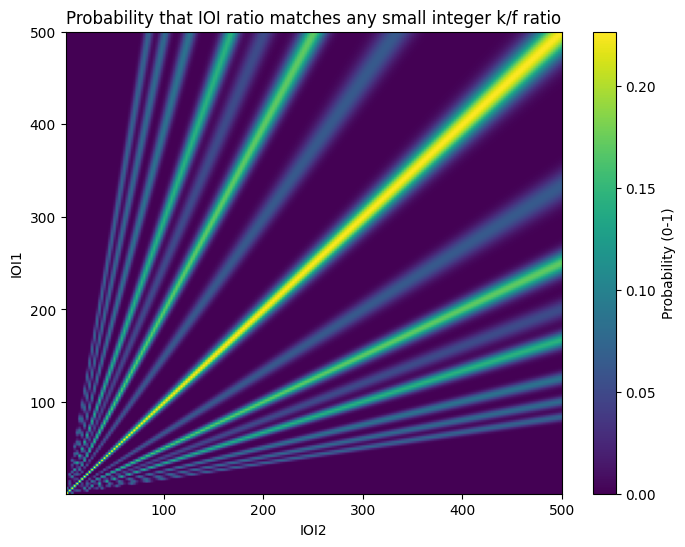

In [3]:
# Small-integer ratio probability based on Weber's Law with vectorized computation

import numpy as np
from scipy.stats import norm

def small_integer_ratio_probability(ioi1, ioi2, s=0.05, max_freq=4,
                                    weight_exponent=1.0, decay=0.0, k_max=None):
    """
    Computes the probability (0-1) that the exact IOI ratio corresponds to any small integer k/f ratio.

    Parameters:
    -----------
    ioi1, ioi2 : float or np.ndarray
        The two inter-onset intervals (can be scalars or arrays of same shape)
    s : float
        Weber fraction for timing uncertainty
    max_freq : int
        Maximum denominator f for target ratios
    weight_exponent : float
        Exponent for weighting smaller f values
    decay : float
        Exponent for weighting longer ratios
    k_max : int or None
        Maximum numerator k (if None, defaults to 4*max_freq)

    Returns:
    --------
    prob : float or np.ndarray
        Probability (0-1) that the IOI ratio is a simple small integer ratio
    """
    # Ensure scalar inputs are treated as arrays
    ioi1 = np.atleast_1d(ioi1)
    ioi2 = np.atleast_1d(ioi2)
    
    # Shape check
    if ioi1.shape != ioi2.shape:
        raise ValueError("ioi1 and ioi2 must have the same shape")
    
    mu1 = np.maximum(ioi1, ioi2)
    mu2 = np.minimum(ioi1, ioi2)

    sigma1 = s * mu1
    sigma2 = s * mu2

    # Delta-method for ratio uncertainty
    mu_R = mu1 / mu2
    sigma_R = np.sqrt(sigma1**2 / mu2**2 + (mu1**2 * sigma2**2) / mu2**4)

    # Define k/f targets
    if k_max is None:
        k_max = max_freq * 4
    fs = np.arange(1, max_freq + 1)
    ks = np.arange(1, k_max + 1)
    f_grid, k_grid = np.meshgrid(fs, ks, indexing='ij')
    targets = (k_grid / f_grid).flatten()
    weights = 1 / (f_grid.flatten()**weight_exponent * targets**decay)

    # Expand for broadcasting
    mu_R_exp = mu_R[..., np.newaxis]
    sigma_R_exp = sigma_R[..., np.newaxis]

    # Probability densities for all targets
    pdf_vals = norm.pdf(targets, loc=mu_R_exp, scale=sigma_R_exp)
    weighted_sum = np.sum(weights * pdf_vals, axis=-1)

    # Max possible sum for normalization (all targets perfectly match)
    max_sum = np.sum(weights * norm.pdf(targets, loc=targets, scale=sigma_R_exp), axis=-1)

    # Avoid division by zero
    prob = np.zeros_like(weighted_sum)
    mask = max_sum > 0
    prob[mask] = weighted_sum[mask] / max_sum[mask]

    # Clamp to [0,1]
    prob = np.clip(prob, 0, 1)

    # Return scalar if inputs were scalar
    if prob.size == 1:
        return float(prob)
    return prob

# ================================
# Example heatmap
# ================================
import matplotlib.pyplot as plt

ioi_values = np.linspace(1, 500, 200)
ioi1_grid, ioi2_grid = np.meshgrid(ioi_values, ioi_values, indexing='ij')
matrix = small_integer_ratio_probability(ioi1_grid, ioi2_grid,
                                         s=0.025, 
                                         max_freq=2,
                                         weight_exponent=1, 
                                         decay=0.4,
                                         k_max=6)

plt.figure(figsize=(8,6))
plt.imshow(matrix, origin='lower', extent=[ioi_values[0], ioi_values[-1],
                                           ioi_values[0], ioi_values[-1]],
           aspect='auto', cmap='viridis')
plt.colorbar(label="Probability (0-1)")
plt.xlabel("IOI2")
plt.ylabel("IOI1")
plt.title("Probability that IOI ratio matches any small integer k/f ratio")
plt.show()


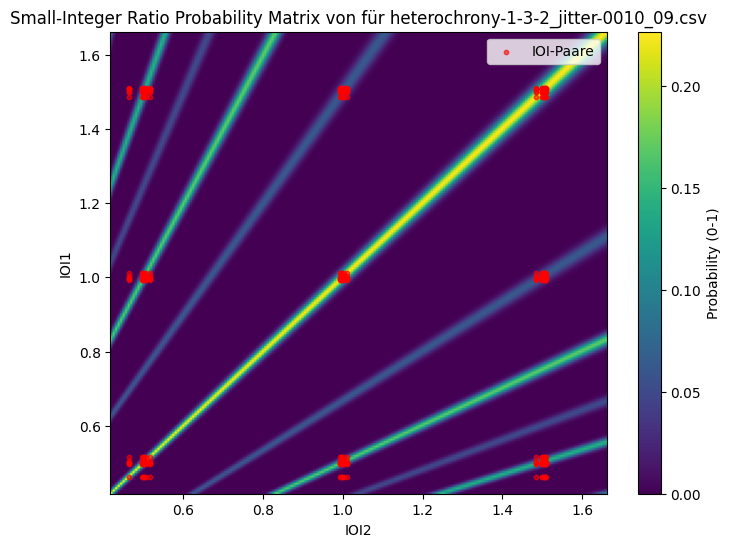

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

def small_integer_ratio_probability(ioi1, ioi2, s=0.05, max_freq=4,
                                    weight_exponent=1.0, decay=0.0, k_max=None):
    ioi1 = np.atleast_1d(ioi1)
    ioi2 = np.atleast_1d(ioi2)
    
    if ioi1.shape != ioi2.shape:
        raise ValueError("ioi1 and ioi2 must have the same shape")
    
    mu1 = np.maximum(ioi1, ioi2)
    mu2 = np.minimum(ioi1, ioi2)
    sigma1 = s * mu1
    sigma2 = s * mu2
    mu_R = mu1 / mu2
    sigma_R = np.sqrt(sigma1**2 / mu2**2 + (mu1**2 * sigma2**2) / mu2**4)

    if k_max is None:
        k_max = max_freq * 4
    fs = np.arange(1, max_freq + 1)
    ks = np.arange(1, k_max + 1)
    f_grid, k_grid = np.meshgrid(fs, ks, indexing='ij')
    targets = (k_grid / f_grid).flatten()
    weights = 1 / (f_grid.flatten()**weight_exponent * targets**decay)

    mu_R_exp = mu_R[..., np.newaxis]
    sigma_R_exp = sigma_R[..., np.newaxis]
    pdf_vals = norm.pdf(targets, loc=mu_R_exp, scale=sigma_R_exp)
    weighted_sum = np.sum(weights * pdf_vals, axis=-1)
    max_sum = np.sum(weights * norm.pdf(targets, loc=targets, scale=sigma_R_exp), axis=-1)

    prob = np.zeros_like(weighted_sum)
    mask = max_sum > 0
    prob[mask] = weighted_sum[mask] / max_sum[mask]
    prob = np.clip(prob, 0, 1)

    if prob.size == 1:
        return float(prob)
    return prob

# ================================
# CSV-Datei einlesen
# ================================
filename = "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-3-2_jitter-0010_09.csv"  # Pfad zur CSV
df = pd.read_csv(filename)
iois = df["IOI"].dropna().values

# Alle IOI-Paare bilden
ioi1_grid_pairs, ioi2_grid_pairs = np.meshgrid(iois, iois, indexing='ij')
matrix_pairs = small_integer_ratio_probability(ioi1_grid_pairs, ioi2_grid_pairs,
                                               s=0.05, max_freq=2,
                                               weight_exponent=1, decay=0.4,
                                               k_max=6)

# Heatmapbereich basierend auf IOI-Werten
ioi_min = 0.9 * iois.min()
ioi_max = 1.1 * iois.max()
ioi_values = np.linspace(ioi_min, ioi_max, 200)
ioi1_grid, ioi2_grid = np.meshgrid(ioi_values, ioi_values, indexing='ij')
matrix_interp = small_integer_ratio_probability(ioi1_grid, ioi2_grid,
                                                s=0.01, max_freq=2,
                                                weight_exponent=1, decay=0.4,
                                                k_max=6)

# ================================
# Plot
# ================================
plt.figure(figsize=(8,6))
plt.imshow(matrix_interp, origin='lower',
           extent=[ioi_values[0], ioi_values[-1], ioi_values[0], ioi_values[-1]],
           aspect='auto', cmap='viridis')
plt.colorbar(label="Probability (0-1)")
plt.xlabel("IOI2")
plt.ylabel("IOI1")
plt.title(f"Small-Integer Ratio Probability Matrix von für {filename.split('/')[-1]}")

# Alle IOI-Paare als rote Punkte eintragen
plt.scatter(ioi1_grid_pairs.flatten(), ioi2_grid_pairs.flatten(), color='red', s=10, alpha=0.6, label="IOI-Paare")
plt.legend()
plt.show()
